In [1]:
!pip install torch


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
PATH = "../Datasets/UCI Dynamic Gas Mixtures"

In [2]:
SEED = 42

In [3]:
name = "Co"

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import copy
import seaborn as sns
import random
import os

In [5]:
class BaselineLSTM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channels = channels

        self.pooling = nn.AvgPool1d(kernel_size=5, stride=5)

        # B,   S, T
        # B*S, 1, T

        # B,  S, T
        # B, 64, H

        # 64, H

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=self.channels, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=False)

        self.lin_head = nn.Linear(in_features=64, out_features=2)

    def forward(self, x):
        x = self.pooling(x)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        x = h[-1]
        pred = self.lin_head(x)
        return pred

In [6]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Максимальная воспроизводимость CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Заставляет PyTorch использовать детерминированные алгоритмы,
    # где это возможно
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

In [7]:
model = BaselineLSTM(channels=15)

In [8]:
x = torch.randn(4, 15, 5000)
y = model(x)

print(y.shape)
assert y.shape == torch.Size([4, 2])
print("се ок")

torch.Size([4, 2])
се ок


In [9]:
X = pd.read_csv(PATH + f"/ethylene_{name.lower()}.txt", sep=r'\s+', skiprows=1, names=['Time', name, 'Ethylene'] + [f's{i}' for i in range(1, 17)])

In [19]:
print(X)

             Time   Co  Ethylene       s1       s3       s4       s5       s6  \
0            0.00  0.0       0.0   -50.85   -41.82     1.30    -4.07   -28.73   
1            0.01  0.0       0.0   -49.40   -42.78     0.49     3.58   -34.55   
2            0.01  0.0       0.0   -40.04   -27.59     0.00    -7.16   -42.14   
3            0.03  0.0       0.0   -47.14   -32.28     4.40   -11.22   -37.94   
4            0.04  0.0       0.0   -33.58   -33.25     6.03     3.42   -34.22   
...           ...  ...       ...      ...      ...      ...      ...      ...   
4208256  42087.51  0.0       0.0  1127.81  2117.39  2247.58  1207.59  1646.73   
4208257  42087.52  0.0       0.0  1140.73  2105.93  2253.69  1216.39  1624.47   
4208258  42087.53  0.0       0.0  1123.99  2111.18  2245.63  1215.36  1628.44   
4208259  42087.54  0.0       0.0  1131.44  2114.76  2249.54  1197.99  1612.17   
4208260  42087.55  0.0       0.0  1130.23  2107.12  2255.64  1211.07  1621.62   

              s7       s8  

In [14]:
X.drop(columns="s2", inplace=True)

In [18]:
print(X.columns)

Index(['Time', 'Co', 'Ethylene', 's1', 's3', 's4', 's5', 's6', 's7', 's8',
       's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16'],
      dtype='str')


In [21]:
time = X["Time"].to_numpy()
y = X[[name, "Ethylene"]].to_numpy(dtype=np.float32)
X = X[[f"s{i}" for i in range(1, 17) if i != 2]].to_numpy(dtype=np.float32)

In [23]:
X.shape

(4208261, 15)

In [24]:
y

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(4208261, 2), dtype=float32)

In [25]:
def find_segments(target):
    changed = np.any(target[1:] != target[:-1], axis=1)

    boundaries = np.concatenate([
        [0],
        np.flatnonzero(changed) + 1,
        [len(target)],
    ])

    return [
        {
            "start": int(start),
            "end": int(end),
            "target": np.median(target[start:end], axis=0),
        }
        for start, end in zip(boundaries[:-1], boundaries[1:])
    ]

In [26]:
window_size = 50 * 100

In [27]:
target_step = 0.5

In [28]:
target_step = np.array([0.5, 0.5], dtype=np.float32)
y_clean = np.round(y / target_step) * target_step

In [29]:
segments = find_segments(y_clean)

In [30]:
len(segments)

373

In [31]:
segments

[{'start': 0, 'end': 9995, 'target': array([0., 0.], dtype=float32)},
 {'start': 9995, 'end': 19995, 'target': array([533.5,   0. ], dtype=float32)},
 {'start': 19995, 'end': 29995, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 29995, 'end': 49996, 'target': array([0., 0.], dtype=float32)},
 {'start': 49996, 'end': 59996, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 59996, 'end': 69994, 'target': array([0., 0.], dtype=float32)},
 {'start': 69994, 'end': 79994, 'target': array([ 0., 10.], dtype=float32)},
 {'start': 79994, 'end': 89994, 'target': array([0., 0.], dtype=float32)},
 {'start': 89994, 'end': 99994, 'target': array([0. , 6.5], dtype=float32)},
 {'start': 99994, 'end': 109994, 'target': array([0., 0.], dtype=float32)},
 {'start': 109994,
  'end': 119994,
  'target': array([200.,   0.], dtype=float32)},
 {'start': 119994, 'end': 129994, 'target': array([0., 0.], dtype=float32)},
 {'start': 129994,
  'end': 139995,
  'target': array([333.5,   0. ], dtype

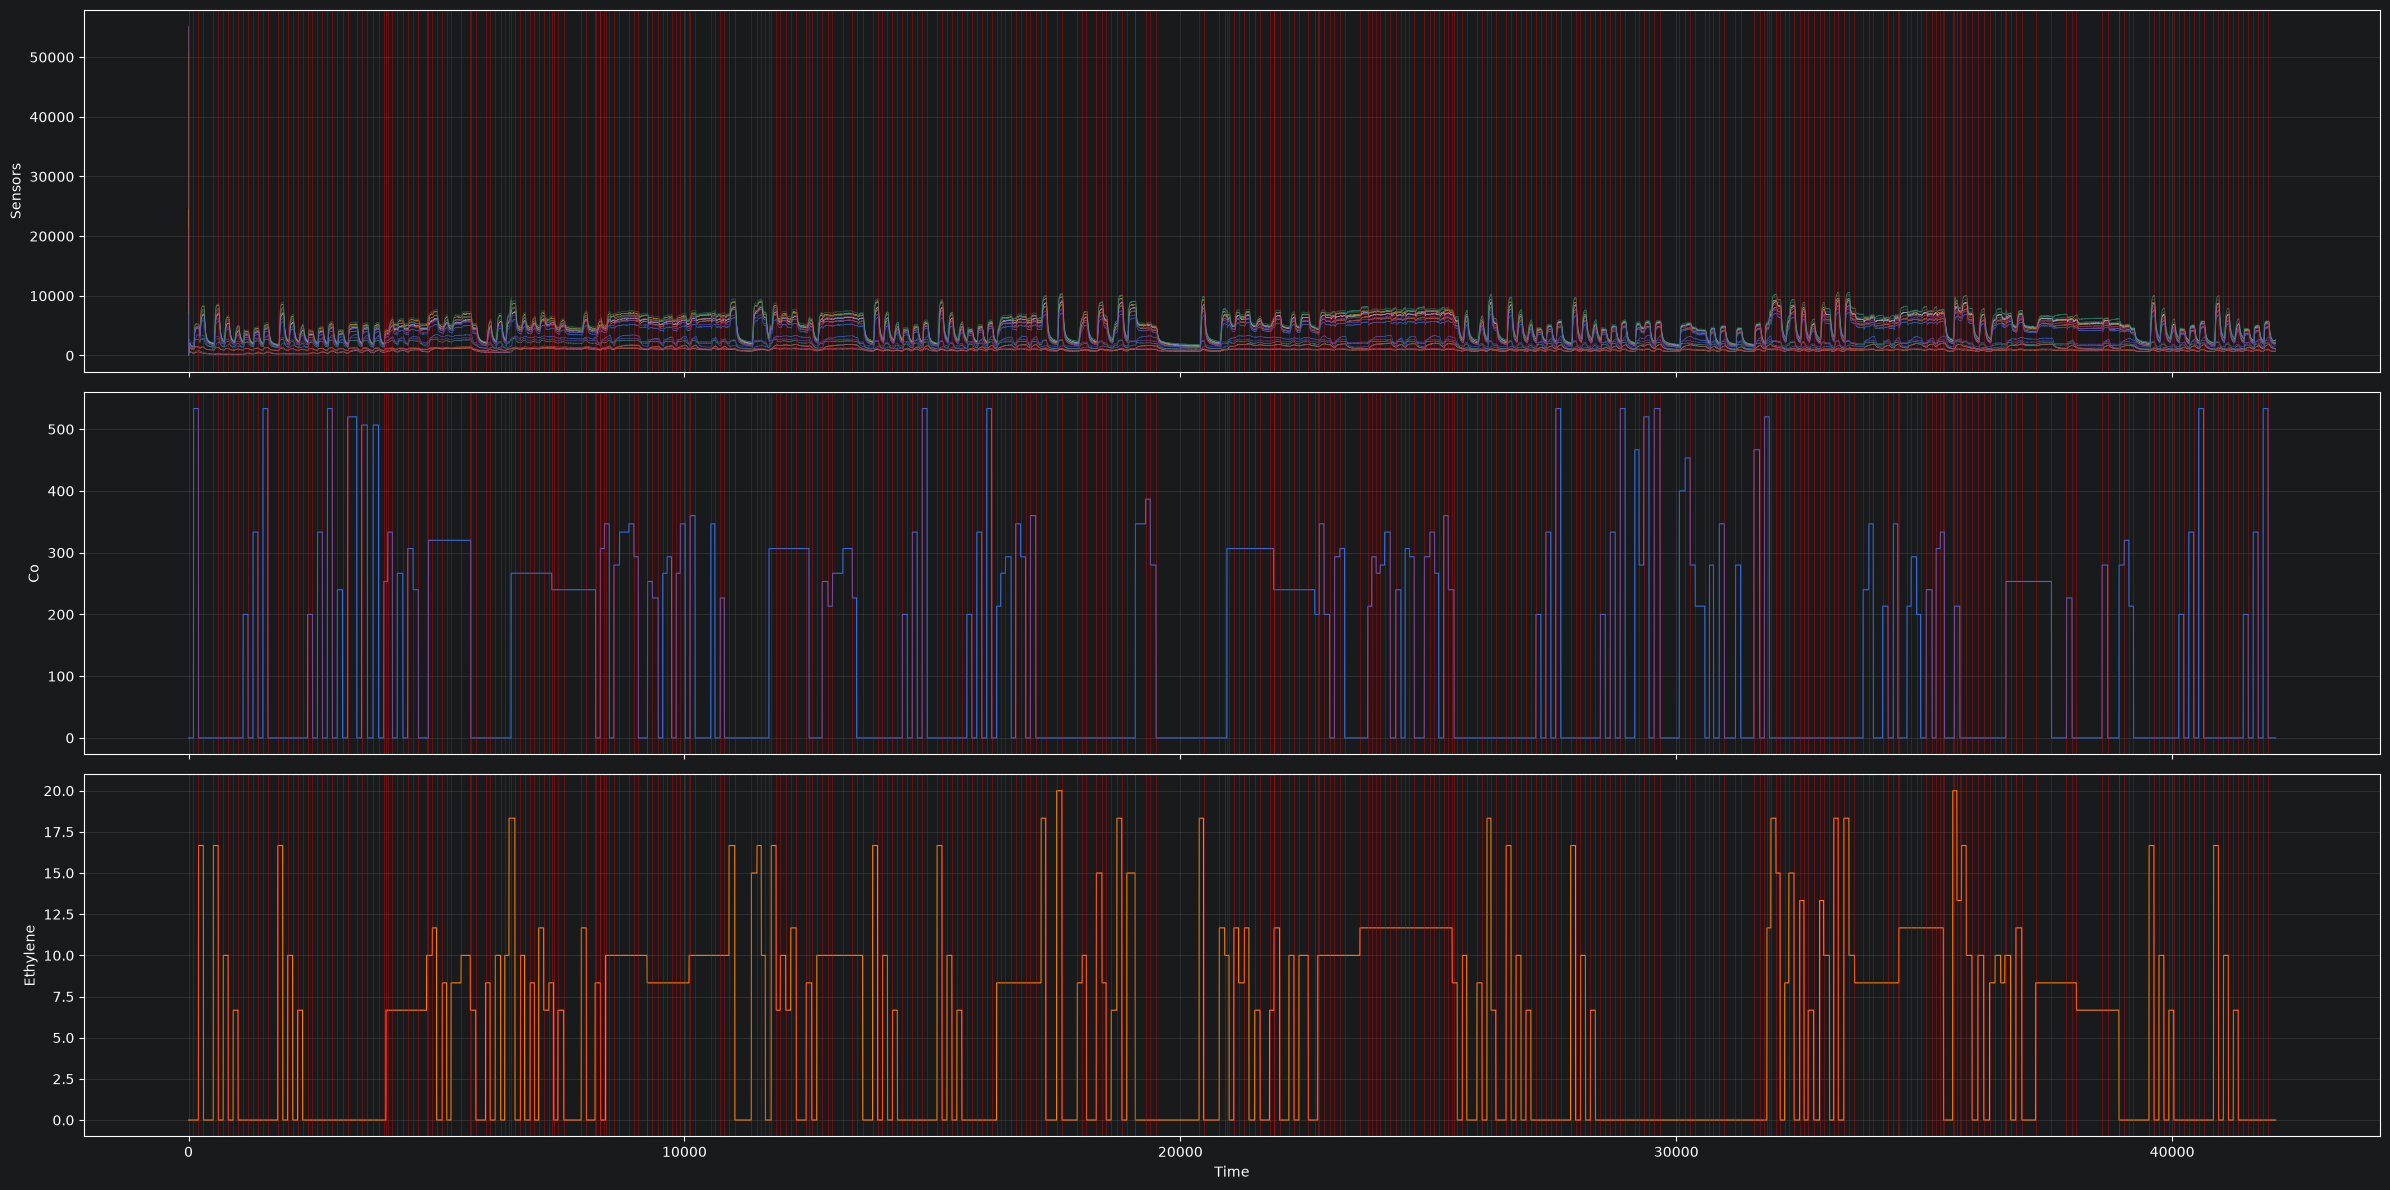

In [32]:
plot_step = 100

fig, axes = plt.subplots(3, 1, figsize=(24, 12), sharex=True)

axes[0].plot(
    time[::plot_step],
        X[::plot_step],
    linewidth=0.5,
    alpha=0.7,
)
axes[0].set_ylabel("Sensors")

axes[1].plot(
    time[::plot_step],
    y[::plot_step, 0],
    linewidth=0.8,
)
axes[1].set_ylabel(name)

axes[2].plot(
    time[::plot_step],
    y[::plot_step, 1],
    color="tab:orange",
    linewidth=0.8,
)
axes[2].set_ylabel("Ethylene")
axes[2].set_xlabel("Time")

for segment in segments[1:]:
    boundary_time = time[segment["start"]]
    for ax in axes:
        ax.axvline(boundary_time, color="red", linewidth=0.5, alpha=0.5)
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [33]:
def make_window_indices(segments, window_size=5000, stride=100):
    samples = []

    for segment in segments:
        segment_start = segment["start"]
        segment_end = segment["end"]

        for end in range(
            segment_start + window_size,
            segment_end + 1,
            stride,
        ):
            start = end - window_size
            samples.append((start, end))

    return samples

In [34]:
generator = np.random.default_rng(SEED)
indices = generator.permutation(len(segments))

n_train = int(0.70 * len(indices))
n_val = int(0.15 * len(indices))

train_segments = [segments[i] for i in indices[:n_train]]
val_segments = [segments[i] for i in indices[n_train:n_train + n_val]]
test_segments = [segments[i] for i in indices[n_train + n_val:]]

train_samples = make_window_indices(train_segments, window_size=5000, stride=100)
val_samples = make_window_indices(val_segments, window_size=5000, stride=500)
test_samples = make_window_indices(test_segments, window_size=5000, stride=500)

print(
    len(train_samples),
    len(val_samples),
    len(test_samples),
)

17304 748 711


In [35]:
class SensorDataset(Dataset):
    def __init__(self, signals, target, samples, signal_mean, signal_std, target_mean, target_std):
        self.signals = np.asarray(signals, dtype=np.float32)
        self.target = np.asarray(target, dtype=np.float32)
        self.samples = samples

        self.signal_mean = np.asarray(signal_mean, dtype=np.float32)
        self.signal_std = np.asarray(signal_std, dtype=np.float32)

        self.target_mean = np.asarray(target_mean, dtype=np.float32)
        self.target_std = np.asarray(target_std, dtype=np.float32)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        start, end = self.samples[index]

        # Сначала [time, channels], чтобы broadcasting работал по каналам
        x = self.signals[start:end]
        x = (x - self.signal_mean) / self.signal_std
        x = x.T  # [channels, time]

        y = self.target[end - 1]
        y = (y - self.target_mean) / self.target_std

        return torch.from_numpy(x), torch.from_numpy(y)

In [36]:
def calculate_signal_stats(signals, segments):
    total_sum = np.zeros(signals.shape[1], dtype=np.float64)
    total_squared_sum = np.zeros(signals.shape[1], dtype=np.float64)
    count = 0

    for segment in segments:
        start = segment["start"]
        end = segment["end"]

        chunk = signals[start:end].astype(np.float64)

        total_sum += chunk.sum(axis=0)
        total_squared_sum += np.square(chunk).sum(axis=0)
        count += len(chunk)

    mean = total_sum / count
    variance = total_squared_sum / count - mean ** 2
    std = np.sqrt(np.maximum(variance, 1e-8))

    return mean.astype(np.float32), std.astype(np.float32)


signal_mean, signal_std = calculate_signal_stats(
    X,
    train_segments,
)

print(signal_mean.shape)  # (16,)
print(signal_std.shape)   # (16,)

(15,)
(15,)


In [37]:
torch.cuda.is_available()

True

In [38]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Ус-во:", device)

Ус-во: cuda


In [39]:
train_target_values = np.stack([
    y[end - 1]
    for start, end in train_samples
]).astype(np.float32)

target_mean = train_target_values.mean(axis=0)
target_std = train_target_values.std(axis=0)

target_std = np.maximum(target_std, 1e-6)

print("Target mean:", target_mean)
print("Target std:", target_std)

Target mean: [117.85946    4.612888]
Target std: [158.38693     5.3722835]


In [40]:
train_dataset = SensorDataset(signals=X, target=y, samples=train_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)
val_dataset = SensorDataset(signals=X, target=y, samples=val_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)
test_dataset = SensorDataset(signals=X, target=y, samples=test_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)

In [41]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

In [42]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)  # [32, 16, 5000]
print(batch_y.shape)  # [32, 2]

pred = model(batch_x)
print(pred.shape)     # [32, 2]

torch.Size([32, 15, 5000])
torch.Size([32, 2])
torch.Size([32, 2])


In [43]:
model = BaselineLSTM(channels=16).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

batch_x, batch_y = next(iter(train_loader))

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

optimizer.zero_grad(set_to_none=True)

pred = model(batch_x)
loss = criterion(pred, batch_y)

print("Prediction shape:", pred.shape)
print("Initial loss:", loss.item())

assert pred.shape == batch_y.shape
assert torch.isfinite(pred).all()
assert torch.isfinite(loss)

loss.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0,
)

optimizer.step()

print("Gradient norm:", gradient_norm.item())
print("Один шаг обучения выполнен")

RuntimeError: Given groups=1, weight of size [32, 16, 7], expected input[32, 15, 1000] to have 16 channels, but got 15 channels instead

In [44]:
debug_model = BaselineLSTM(channels=16).to(device)

debug_optimizer = torch.optim.Adam(
    debug_model.parameters(),
    lr=1e-3,
)

batch_x, batch_y = next(iter(train_loader))
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

debug_model.train()

for step in range(100):
    debug_optimizer.zero_grad(set_to_none=True)

    pred = debug_model(batch_x)
    loss = criterion(pred, batch_y)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        debug_model.parameters(),
        max_norm=1.0,
    )

    debug_optimizer.step()

    if step % 10 == 0 or step == 99:
        print(
            f"Step {step:03d}: "
            f"loss={loss.item():.6f}"
        )

RuntimeError: Given groups=1, weight of size [32, 16, 7], expected input[32, 15, 1000] to have 16 channels, but got 15 channels instead

In [45]:
del debug_model
del debug_optimizer

if device.type == "cuda":
    torch.cuda.empty_cache()

In [46]:
seed_everything(SEED)
model = BaselineLSTM(channels=15).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [47]:
def run_epoch(model, loader, criterion, device, target_mean, target_std, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    target_mean_t = torch.as_tensor(target_mean, dtype=torch.float32, device=device)
    target_std_t = torch.as_tensor(target_std, dtype=torch.float32, device=device)

    number_of_targets = len(target_mean)

    total_loss = 0.0
    total_examples = 0

    absolute_error_sum = torch.zeros(number_of_targets, dtype=torch.float32, device=device)
    squared_error_sum = torch.zeros(number_of_targets, dtype=torch.float32, device=device)

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            pred_normalized = model(batch_x)

            loss = criterion(pred_normalized, batch_y)

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

        batch_size = batch_x.shape[0]

        total_loss += loss.item() * batch_size
        total_examples += batch_size

        with torch.no_grad():
            pred_original = pred_normalized * target_std_t + target_mean_t
            y_original = batch_y * target_std_t + target_mean_t
            errors = pred_original - y_original

            absolute_error_sum += torch.abs(errors).sum(dim=0)
            squared_error_sum += torch.square(errors).sum(dim=0)

    average_loss = total_loss / total_examples
    mae = absolute_error_sum / total_examples
    rmse = torch.sqrt(
        squared_error_sum / total_examples
    )

    return {"loss": average_loss, "mae": mae.cpu().numpy(), "rmse": rmse.cpu().numpy()}

In [48]:
assert len(train_dataset) > 0
assert len(val_dataset) > 0
assert len(test_dataset) > 0

assert np.isfinite(X).all()
assert np.isfinite(y).all()
assert np.isfinite(signal_mean).all()
assert np.isfinite(signal_std).all()
assert np.isfinite(target_mean).all()
assert np.isfinite(target_std).all()

batch_x, batch_y = next(iter(train_loader))

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("X:", batch_x.shape)
print("y:", batch_y.shape)

print("X finite:", torch.isfinite(batch_x).all().item())
print("y finite:", torch.isfinite(batch_y).all().item())
print("X mean:", batch_x.mean().item())
print("X std:", batch_x.std().item())
print("y mean:", batch_y.mean(dim=0))
print("y std:", batch_y.std(dim=0))

Train samples: 17304
Val samples: 748
Test samples: 711
X: torch.Size([32, 15, 5000])
y: torch.Size([32, 2])
X finite: True
y finite: True
X mean: -0.2258116900920868
X std: 1.0176734924316406
y mean: tensor([-0.2785, -0.2770])
y std: tensor([0.8701, 0.9381])


In [49]:
num_epochs = 30

In [50]:
best_val_loss = float("inf")
best_model_state = None
best_epoch = None

history = {
    "train_loss": [],
    "val_loss": [],
    f"train_{name.lower()}_mae": [],
    "train_ethylene_mae": [],
    f"val_{name.lower()}_mae": [],
    "val_ethylene_mae": [],
}

In [51]:
import time
training_started = time.perf_counter()

for epoch in range(1, num_epochs + 1):
    epoch_started = time.perf_counter()

    # обучение
    train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
        optimizer=optimizer,
    )

    # аалидация
    val_metrics = run_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
        optimizer=None,
    )

    # сохр для графиков
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history[f"train_{name.lower()}_mae"].append(train_metrics["mae"][0])
    history["train_ethylene_mae"].append(train_metrics["mae"][1])
    history[f"val_{name.lower()}_mae"].append(val_metrics["mae"][0])
    history["val_ethylene_mae"].append(val_metrics["mae"][1])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_state_dict": best_model_state,
                "signal_mean": signal_mean,
                "signal_std": signal_std,
                "target_mean": target_mean,
                "target_std": target_std,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "history": history,
            },
            f"{name.lower()}_baseline_cnn_lstm_best.pt",
        )

    epoch_seconds = time.perf_counter() - epoch_started
    total_seconds = time.perf_counter() - training_started

    print(f"Epoch {epoch:02d}/{num_epochs}")
    print(f"  Time: {epoch_seconds / 60:.1f} min")
    print(
        f"  Normalized MSE: "
        f"train={train_metrics['loss']:.5f}, "
        f"val={val_metrics['loss']:.5f}"
    )

    print(
        f"  Train MAE: "
        f"{name}={train_metrics['mae'][0]:.3f}, "
        f"Ethylene={train_metrics['mae'][1]:.3f}"
    )

    print(
        f"  Val MAE:   "
        f"{name}={val_metrics['mae'][0]:.3f}, "
        f"Ethylene={val_metrics['mae'][1]:.3f}"
    )

    print(
        f"  Val RMSE:  "
        f"{name}={val_metrics['rmse'][0]:.3f}, "
        f"Ethylene={val_metrics['rmse'][1]:.3f}"
    )
    print(
        f"  Total time: {total_seconds / 60:.1f} min"
    )

    print()

Epoch 01/30
  Time: 0.2 min
  Normalized MSE: train=0.04880, val=0.01236
  Train MAE: Co=17.335, Ethylene=0.521
  Val MAE:   Co=12.168, Ethylene=0.302
  Val RMSE:  Co=20.893, Ethylene=0.460
  Total time: 0.2 min

Epoch 02/30
  Time: 0.1 min
  Normalized MSE: train=0.00577, val=0.00931
  Train MAE: Co=6.650, Ethylene=0.194
  Val MAE:   Co=10.651, Ethylene=0.248
  Val RMSE:  Co=17.683, Ethylene=0.421
  Total time: 0.3 min

Epoch 03/30
  Time: 0.1 min
  Normalized MSE: train=0.00335, val=0.00346
  Train MAE: Co=4.967, Ethylene=0.159
  Val MAE:   Co=4.864, Ethylene=0.235
  Val RMSE:  Co=9.057, Ethylene=0.324
  Total time: 0.4 min

Epoch 04/30
  Time: 0.1 min
  Normalized MSE: train=0.00260, val=0.01312
  Train MAE: Co=4.480, Ethylene=0.132
  Val MAE:   Co=13.983, Ethylene=0.231
  Val RMSE:  Co=23.364, Ethylene=0.359
  Total time: 0.6 min

Epoch 05/30
  Time: 0.1 min
  Normalized MSE: train=0.00323, val=0.00307
  Train MAE: Co=4.933, Ethylene=0.147
  Val MAE:   Co=4.495, Ethylene=0.201
  Va

In [52]:
if best_model_state is None:
    raise RuntimeError("Лучшая модель не была сохранена")

model.load_state_dict(best_model_state)

<All keys matched successfully>

In [53]:
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 6
Best validation loss: 0.002526621458763107


In [54]:
test_metrics = run_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    target_mean=target_mean,
    target_std=target_std,
    optimizer=None,
)

print("Test results")
print(
    f"  Normalized MSE: "
    f"{test_metrics['loss']:.5f}"
)

print(
    f"  {name}: "
    f"MAE={test_metrics['mae'][0]:.3f}, "
    f"RMSE={test_metrics['rmse'][0]:.3f}"
)

print(
    f"  Ethylene: "
    f"MAE={test_metrics['mae'][1]:.3f}, "
    f"RMSE={test_metrics['rmse'][1]:.3f}"
)

Test results
  Normalized MSE: 0.00440
  Co: MAE=4.628, RMSE=12.209
  Ethylene: MAE=0.166, RMSE=0.287


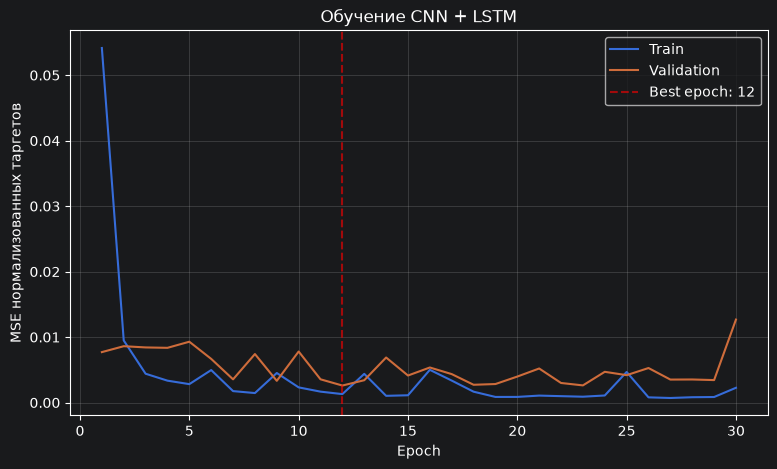

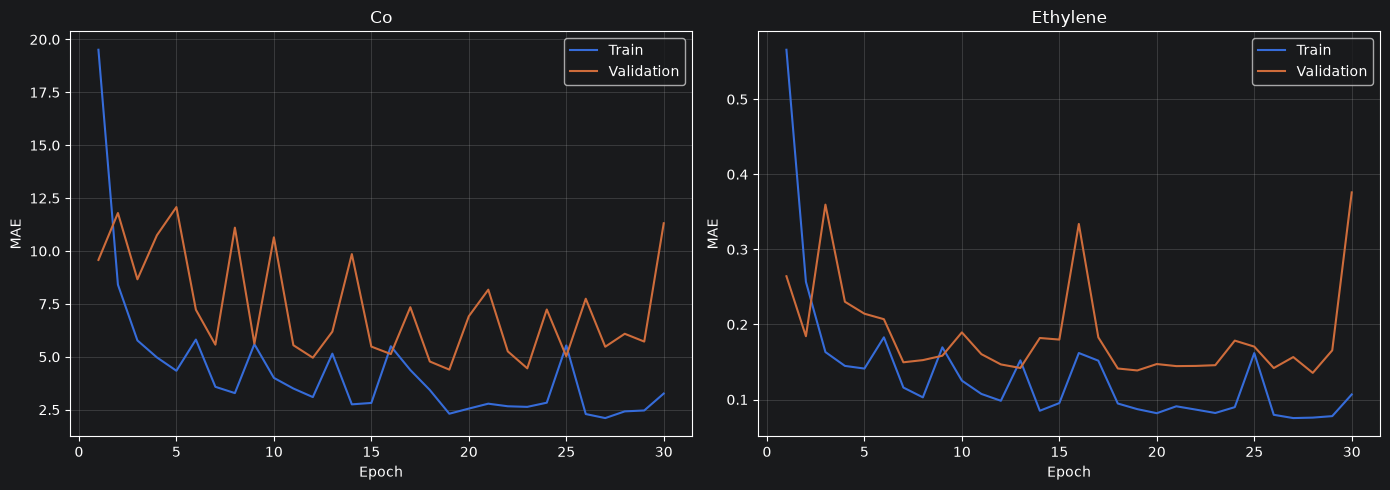

In [44]:
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train",
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("MSE нормализованных таргетов")
plt.title("Обучение CNN + LSTM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# %%
# Графики MAE отдельно для двух газов

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history[f"train_{name.lower()}_mae"],
    label="Train",
)

axes[0].plot(
    epochs,
    history[f"val_{name.lower()}_mae"],
    label="Validation",
)

axes[0].set_title(name)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_ethylene_mae"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_ethylene_mae"],
    label="Validation",
)

axes[1].set_title("Ethylene")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
def collect_predictions(
    model,
    loader,
    device,
    target_mean,
    target_std,
):
    model.eval()

    target_mean_t = torch.as_tensor(
        target_mean,
        dtype=torch.float32,
        device=device,
    )

    target_std_t = torch.as_tensor(
        target_std,
        dtype=torch.float32,
        device=device,
    )

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            pred_normalized = model(batch_x)

            pred = (
                pred_normalized * target_std_t
                + target_mean_t
            )

            true = (
                batch_y * target_std_t
                + target_mean_t
            )

            all_predictions.append(pred.cpu())
            all_targets.append(true.cpu())

    return (
        torch.cat(all_predictions).numpy(),
        torch.cat(all_targets).numpy(),
    )


test_pred, test_true = collect_predictions(
    model,
    test_loader,
    device,
    target_mean,
    target_std,
)

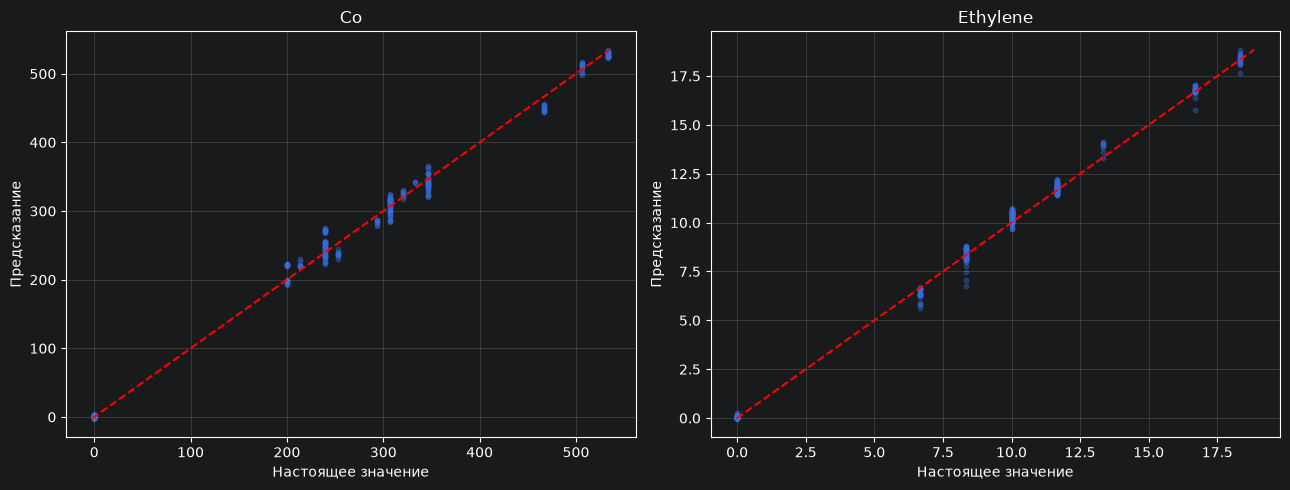

In [46]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

names = [name, "Ethylene"]

for i, name in enumerate(names):
    axes[i].scatter(
        test_true[:, i],
        test_pred[:, i],
        s=10,
        alpha=0.35,
    )

    minimum = min(
        test_true[:, i].min(),
        test_pred[:, i].min(),
    )

    maximum = max(
        test_true[:, i].max(),
        test_pred[:, i].max(),
    )

    axes[i].plot(
        [minimum, maximum],
        [minimum, maximum],
        color="red",
        linestyle="--",
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Настоящее значение")
    axes[i].set_ylabel("Предсказание")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
for i, name in enumerate([name, "Ethylene"]):
    true = test_true[:, i]
    pred = test_pred[:, i]

    zero_mask = true == 0
    nonzero_mask = true > 0

    print(name)

    if zero_mask.any():
        zero_mae = np.abs(
            pred[zero_mask] - true[zero_mask]
        ).mean()

        print("  MAE при target = 0:", zero_mae)

    if nonzero_mask.any():
        nonzero_mae = np.abs(
            pred[nonzero_mask] - true[nonzero_mask]
        ).mean()

        print("  MAE при target > 0:", nonzero_mae)

Ethylene
  MAE при target = 0: 0.37517327
  MAE при target > 0: 10.914254
Ethylene
  MAE при target = 0: 0.01853863
  MAE при target > 0: 0.26378778


Ethylene


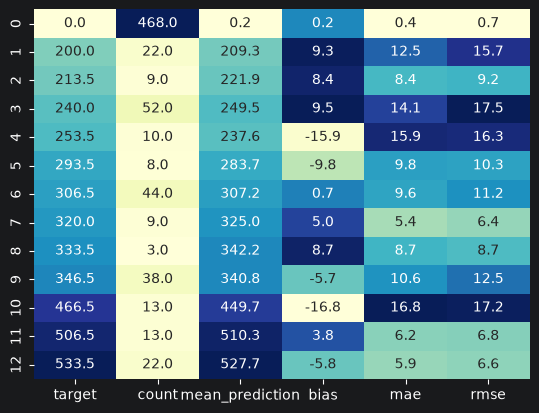

Ethylene


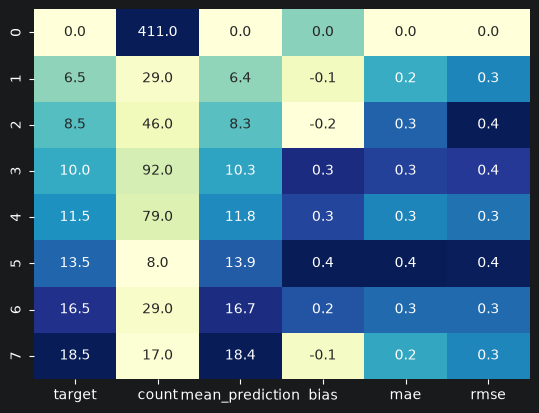

In [48]:
def metrics_by_target_value(
    true,
    pred,
    name,
    round_step=0.5,
):
    values = (
        np.round(true / round_step)
        * round_step
    )

    table = pd.DataFrame({
        "target": values,
        "prediction": pred,
    })

    table["error"] = (
        table["prediction"] - table["target"]
    )

    result = (
        table
        .groupby("target")
        .agg(
            count=("error", "size"),
            mean_prediction=("prediction", "mean"),
            bias=("error", "mean"),
            mae=("error", lambda x: np.abs(x).mean()),
            rmse=("error", lambda x: np.sqrt(np.square(x).mean())),
        )
        .reset_index()
    )

    print(name)
    df_normalized = (result - result.min(axis=0)) / (result.max(axis=0) - result.min(axis=0))

# Шаг 2: Строим heatmap по нормализованным данным, но подписи (annot) берем из исходных
    sns.heatmap(df_normalized, annot=result, fmt='.1f', cmap='YlGnBu', cbar=False)
    plt.show()

    return result


co_table = metrics_by_target_value(
    test_true[:, 0],
    test_pred[:, 0],
    name=name,
)

ethylene_table = metrics_by_target_value(
    test_true[:, 1],
    test_pred[:, 1],
    name="Ethylene",
)